# FootShellGaussian Foot Prior Alignment Playground

This notebook is for understanding the first foot-prior step before training.

It loads:

- the reconstructed GShell shoe mesh
- the watertight GShell mesh
- the neutral SUPR right-foot mesh
- the SUPR-foot SDF grid

Then it aligns the foot inside the shoe and colors shoe regions using the foot SDF.

Nothing in this notebook trains a model. This is a diagnostic and visualization notebook.


In [1]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "5")

from pathlib import Path
import sys
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

FOOTSHELL_ROOT = Path("/data/abelde/projects/active/Shell_Gaussian/FootShellGaussian")
PROJECT_ROOT = FOOTSHELL_ROOT.parent
if str(FOOTSHELL_ROOT) not in sys.path:
    sys.path.insert(0, str(FOOTSHELL_ROOT))

# Jupyter keeps imported modules alive across cell edits. Reload the local package
# so newly added helpers in foot_prior/__init__.py are visible without a kernel restart.
import importlib
import foot_prior as _foot_prior
import foot_prior.foot_alignment as _foot_alignment
importlib.reload(_foot_alignment)
importlib.reload(_foot_prior)

from foot_prior import (
    FootAlignmentConfig,
    FootSDFGrid,
    MeshData,
    build_alignment_from_meshes,
    classify_shoe_points,
    colors_from_regions,
    detect_shoe_opening_boundary,
    get_single_boundary_loop,
    load_triangle_mesh,
    make_hybrid_mesh,
    mesh_bounds,
    principal_yaw_degrees,
    region_summary,
    select_faces_below_axis,
    select_faces_below_signed_axis,
    write_colored_ply,
    write_obj_mesh,
)

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch: 1.13.1 cuda: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Paths

Start with the shoe we already debugged. Later I can change `SHOE_NAME`, `SHELL_MESH_PATH`, or `WATERTIGHT_MESH_PATH` to inspect another reconstruction.


In [2]:
SHOE_NAME = "Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids"
DATASET_SCENE = Path("/data/abelde/datasets/processed/gshell_shoes") / SHOE_NAME
GSHELL_DEBUG_OUTPUT = PROJECT_ROOT / "baselines" / "GShell" / "output" / f"{SHOE_NAME}_sole_debug"

SHELL_MESH_PATH = GSHELL_DEBUG_OUTPUT / "mesh" / "mesh.obj"
WATERTIGHT_MESH_PATH = GSHELL_DEBUG_OUTPUT / "mesh_watertight" / "mesh.obj"
FOOT_OBJ_PATH = PROJECT_ROOT / "baselines" / "SUPR" / "output" / "debug_playground" / "supr_male_right_foot_neutral.obj"
FOOT_SDF_PATH = FOOTSHELL_ROOT / "data" / "foot_prior" / "supr_male_right_foot_sdf.npz"
OUT_DIR = FOOTSHELL_ROOT / "output" / "foot_prior_debug" / SHOE_NAME

for label, path in {
    "dataset scene": DATASET_SCENE,
    "shell mesh": SHELL_MESH_PATH,
    "watertight mesh": WATERTIGHT_MESH_PATH,
    "foot OBJ": FOOT_OBJ_PATH,
    "foot SDF": FOOT_SDF_PATH,
}.items():
    print(f"{label:16s}: {path} | exists={path.exists()}")


dataset scene   : /data/abelde/datasets/processed/gshell_shoes/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids | exists=True
shell mesh      : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh/mesh.obj | exists=True
watertight mesh : /data/abelde/projects/active/Shell_Gaussian/baselines/GShell/output/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids_sole_debug/mesh_watertight/mesh.obj | exists=True
foot OBJ        : /data/abelde/projects/active/Shell_Gaussian/baselines/SUPR/output/debug_playground/supr_male_right_foot_neutral.obj | exists=True
foot SDF        : /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/data/foot_prior/supr_male_right_foot_sdf.npz | exists=True


## 2. Load Meshes And SDF

The shell mesh is the mSDF-cut surface. The watertight mesh is the underlying closed surface before the mSDF cutting creates openings/holes.


In [3]:
shell_mesh = load_triangle_mesh(SHELL_MESH_PATH)
watertight_mesh = load_triangle_mesh(WATERTIGHT_MESH_PATH)
foot_mesh = load_triangle_mesh(FOOT_OBJ_PATH)
foot_sdf = FootSDFGrid.from_npz(str(FOOT_SDF_PATH), device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))

print("shell mesh:     ", shell_mesh.vertices.shape, shell_mesh.faces.shape)
print("watertight mesh:", watertight_mesh.vertices.shape, watertight_mesh.faces.shape)
print("foot mesh:      ", foot_mesh.vertices.shape, foot_mesh.faces.shape)
print("foot SDF grid:  ", tuple(foot_sdf.sdf.shape), "bounds", foot_sdf.bounds_min.detach().cpu().numpy(), foot_sdf.bounds_max.detach().cpu().numpy())


shell mesh:      (2005, 3) (3052, 3)
watertight mesh: (1616, 3) (3228, 3)
foot mesh:       (266, 3) (515, 3)
foot SDF grid:   (1, 1, 128, 128, 128) bounds [-0.19143257 -1.3869797  -0.14568643] [-0.02844138 -1.2218517   0.18629017]


In [4]:
def print_bounds(name, vertices):
    mn, mx, size, center = mesh_bounds(vertices)
    print(name)
    print("  min:   ", mn)
    print("  max:   ", mx)
    print("  size:  ", size)
    print("  center:", center)

print_bounds("shell", shell_mesh.vertices)
print_bounds("watertight", watertight_mesh.vertices)
print_bounds("raw SUPR foot", foot_mesh.vertices)


shell
  min:    [-0.14739399 -0.06755324 -0.06746243]
  max:    [0.14367275 0.07245061 0.05416977]
  size:   [0.29106674 0.14000386 0.1216322 ]
  center: [-0.00186062  0.00244868 -0.00664633]
watertight
  min:    [-0.14739399 -0.06755324 -0.06746243]
  max:    [0.14367275 0.07327574 0.05416977]
  size:   [0.29106674 0.140829   0.1216322 ]
  center: [-0.00186062  0.00286125 -0.00664633]
raw SUPR foot
  min:    [-0.16143256 -1.3569797  -0.11568644]
  max:    [-0.05844138 -1.2518517   0.15629017]
  size:   [0.10299119 0.10512805 0.27197662]
  center: [-0.10993697 -1.3044157   0.02030187]


## 3. Plot Helpers

The plot uses GShell shoe coordinates directly. The foot is transformed into the same coordinates by the alignment object.


In [5]:
def _sample_faces(mesh, max_faces=2500):
    faces = mesh.faces
    if faces.shape[0] <= max_faces:
        return faces
    idx = np.linspace(0, faces.shape[0] - 1, max_faces).astype(np.int64)
    return faces[idx]


def display_axis_order(alignment=None):
    cfg = alignment.config if alignment is not None else FootAlignmentConfig()
    return [cfg.shoe_length_axis, cfg.shoe_width_axis, cfg.shoe_up_axis]


def display_axis_signs(alignment=None):
    cfg = alignment.config if alignment is not None else FootAlignmentConfig()
    return np.asarray([cfg.shoe_length_sign, cfg.shoe_width_sign, cfg.shoe_up_sign], dtype=np.float32)


def to_display_coords(vertices, alignment=None):
    vertices = np.asarray(vertices)
    return vertices[:, display_axis_order(alignment)] * display_axis_signs(alignment)[None, :]


def set_axes_equal(ax, vertices_list):
    all_vertices = np.concatenate([np.asarray(v).reshape(-1, 3) for v in vertices_list if np.asarray(v).size], axis=0)
    mn = all_vertices.min(axis=0)
    mx = all_vertices.max(axis=0)
    center = (mn + mx) * 0.5
    radius = max((mx - mn).max() * 0.55, 1e-6)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
        ax.set_proj_type("ortho")
    except Exception:
        pass


def add_mesh(ax, mesh, color="#9ecae1", alpha=0.55, max_faces=2500, linewidth=0.08, alignment=None):
    faces = _sample_faces(mesh, max_faces=max_faces)
    vertices_display = to_display_coords(mesh.vertices, alignment)
    poly = Poly3DCollection(vertices_display[faces], alpha=alpha, linewidths=linewidth)
    poly.set_facecolor(color)
    poly.set_edgecolor("#222222")
    ax.add_collection3d(poly)
    return vertices_display


def plot_alignment(alignment, elev=10, azim=-70, show_shell=True, show_watertight=True, title="aligned foot inside shoe"):
    foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
    aligned_mesh = MeshData(foot_aligned, foot_mesh.faces)

    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    vertices_for_bounds = []

    if show_watertight:
        vertices_for_bounds.append(add_mesh(ax, watertight_mesh, color="#bdbdbd", alpha=0.18, max_faces=2500, linewidth=0.05, alignment=alignment))
    if show_shell:
        vertices_for_bounds.append(add_mesh(ax, shell_mesh, color="#74add1", alpha=0.38, max_faces=3500, linewidth=0.05, alignment=alignment))

    vertices_for_bounds.append(add_mesh(ax, aligned_mesh, color="#fdae6b", alpha=0.82, max_faces=900, linewidth=0.22, alignment=alignment))

    cfg = alignment.config
    opening = detect_shoe_opening_boundary(shell_mesh, cfg)
    if opening is not None:
        opening_vertices = shell_mesh.vertices[np.asarray(opening["vertices"], dtype=np.int64)]
        opening_display = to_display_coords(opening_vertices, alignment)
        ax.scatter(
            opening_display[:, 0],
            opening_display[:, 1],
            opening_display[:, 2],
            color="#542788",
            s=12,
            depthshade=False,
        )

    ankle_loop = alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
    ankle_loop_display = to_display_coords(np.concatenate([ankle_loop, ankle_loop[:1]], axis=0), alignment)
    ax.plot(ankle_loop_display[:, 0], ankle_loop_display[:, 1], ankle_loop_display[:, 2], color="#d73027", linewidth=2.0)

    shoe_min, shoe_max, _, _ = mesh_bounds(watertight_mesh.vertices)
    corners = np.zeros((5, 3), dtype=np.float32)
    corners[:, cfg.shoe_length_axis] = [shoe_min[cfg.shoe_length_axis], shoe_max[cfg.shoe_length_axis], shoe_max[cfg.shoe_length_axis], shoe_min[cfg.shoe_length_axis], shoe_min[cfg.shoe_length_axis]]
    corners[:, cfg.shoe_width_axis] = [shoe_min[cfg.shoe_width_axis], shoe_min[cfg.shoe_width_axis], shoe_max[cfg.shoe_width_axis], shoe_max[cfg.shoe_width_axis], shoe_min[cfg.shoe_width_axis]]
    corners[:, cfg.shoe_up_axis] = alignment.plantar_z + cfg.plantar_band * _foot_alignment.axis_sign(cfg.shoe_up_sign)
    corners_display = to_display_coords(corners, alignment)
    ax.plot(corners_display[:, 0], corners_display[:, 1], corners_display[:, 2], color="#2166ac", linewidth=1.5)

    set_axes_equal(ax, vertices_for_bounds)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 4. Default Principal-Axis Alignment

The corrected raw shoe coordinate model for this scene is:

```text
GShell X = shoe length
GShell Y = shoe height / opening-to-sole axis
GShell Z = shoe width
```

The missing sole/base is on the `+Y` side of this raw shell, so anatomical foot-up maps to `-Y`:

```text
SUPR +Z toes      -> GShell +X
SUPR +Y ankle/up  -> GShell -Y
SUPR -Y sole      -> GShell +Y
SUPR +X width     -> GShell +Z
```

The detector now skips the large missing-sole boundary before selecting the purple collar/opening boundary. The notebook display flips the signed height axis so the opening/up side appears visually upward in the plots.


shoe principal yaw degrees in x-z length/width plane: -6.60911216210538
{
  "foot_to_shoe": [
    [
      -0.09607548266649246,
      0.0,
      0.8292011022567749,
      -0.03869783505797386
    ],
    [
      0.0,
      -0.8347484469413757,
      0.0,
      -1.091460943222046
    ],
    [
      0.8292011022567749,
      0.0,
      0.09607548266649246,
      0.08957283198833466
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "shoe_to_foot": [
    [
      -0.13788002729415894,
      0.0,
      1.190004587173462,
      -0.11192774027585983
    ],
    [
      -0.0,
      -1.1979657411575317,
      -0.0,
      -1.307532787322998
    ],
    [
      1.190004587173462,
      0.0,
      0.13788002729415894,
      0.03370029851794243
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "scale": 0.8347484210259871,
  "plantar_z": 0.041275739669799805,
  "auto_yaw_degrees": -6.60911216210538,
  "config": {
    "length_ratio": 0.78,
    "scale_multiplier": 1.0

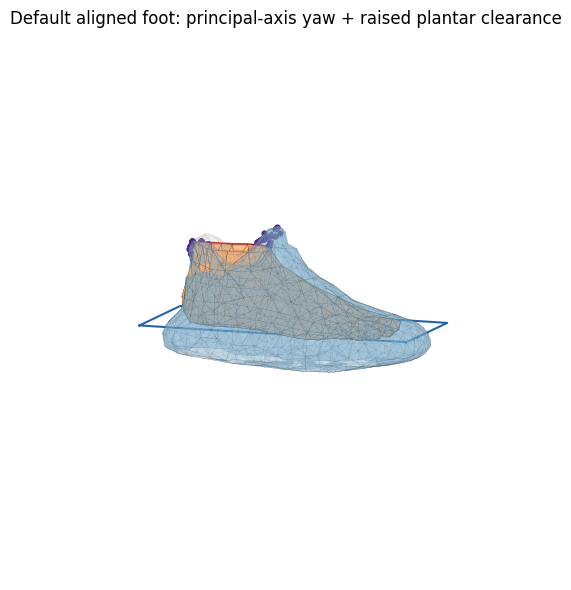

In [6]:
def make_alignment(
    length_ratio=0.78,
    scale_multiplier=1.0,
    plantar_clearance=0.032,
    plantar_band=0.012,
    surface_band=0.005,
    clearance=0.005,
    ankle_radius=0.025,
    shoe_length_axis=0,
    shoe_up_axis=1,
    shoe_width_axis=2,
    shoe_length_sign=1.0,
    shoe_up_sign=-1.0,
    shoe_width_sign=1.0,
    auto_yaw=True,
    align_ankle_to_opening=True,
    yaw_degrees=0.0,
    pitch_degrees=0.0,
    roll_degrees=0.0,
    tx=0.0,
    ty=0.0,
    tz=0.0,
):
    config = FootAlignmentConfig(
        length_ratio=length_ratio,
        scale_multiplier=scale_multiplier,
        plantar_clearance=plantar_clearance,
        plantar_band=plantar_band,
        surface_band=surface_band,
        clearance=clearance,
        ankle_radius=ankle_radius,
        shoe_length_axis=shoe_length_axis,
        shoe_up_axis=shoe_up_axis,
        shoe_width_axis=shoe_width_axis,
        shoe_length_sign=shoe_length_sign,
        shoe_up_sign=shoe_up_sign,
        shoe_width_sign=shoe_width_sign,
        align_ankle_to_opening=align_ankle_to_opening,
        auto_yaw=auto_yaw,
        yaw_degrees=yaw_degrees,
        pitch_degrees=pitch_degrees,
        roll_degrees=roll_degrees,
        translation_offset=(tx, ty, tz),
    )
    return build_alignment_from_meshes(foot_mesh=foot_mesh, shoe_mesh=watertight_mesh, opening_mesh=shell_mesh, config=config)

print("shoe principal yaw degrees in x-z length/width plane:", principal_yaw_degrees(watertight_mesh.vertices, length_axis=0, width_axis=2))
alignment = make_alignment()
print(json.dumps(alignment.to_dict(), indent=2)[:2200])
foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
print_bounds("aligned foot", foot_aligned)
plot_alignment(alignment, title="Default aligned foot: principal-axis yaw + raised plantar clearance")


## 5. Turntable Views

Use these views to check whether the foot is actually sitting where a foot should sit: inside the upper and above the sole.


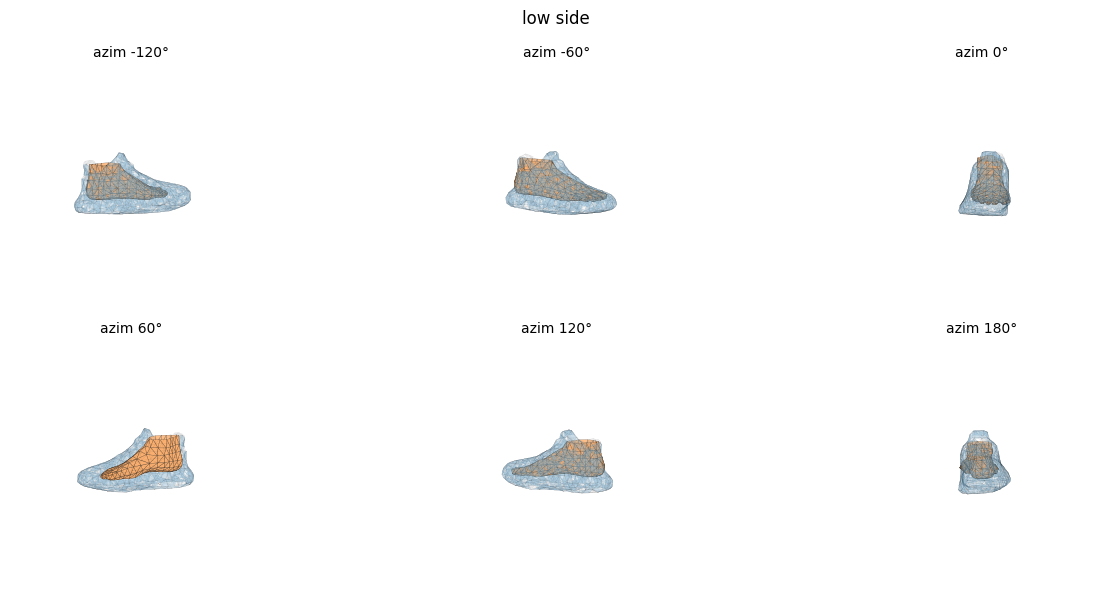

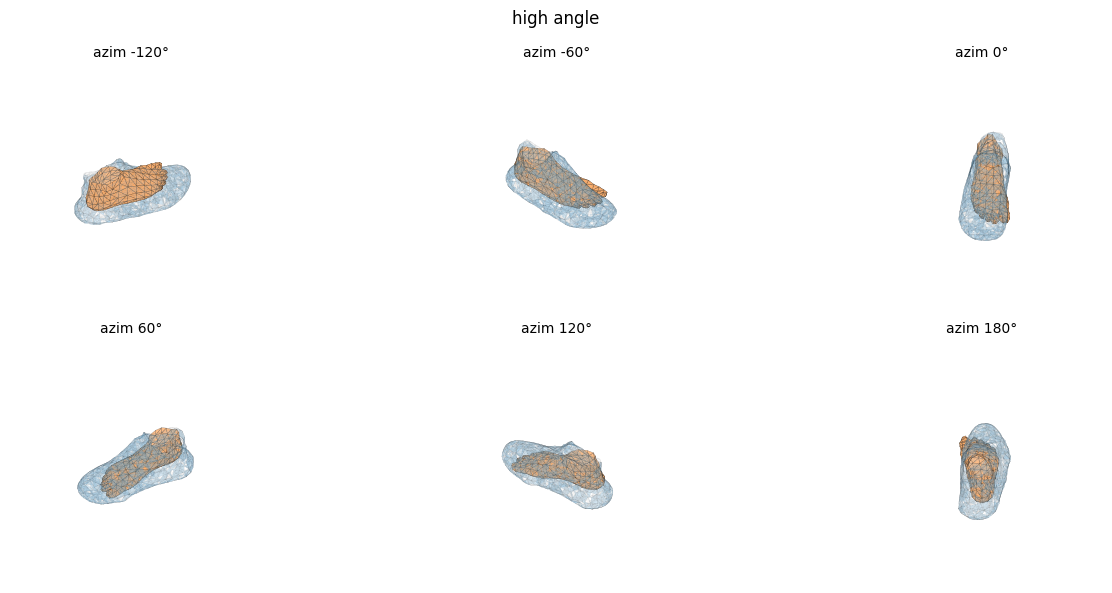

In [7]:
def plot_turntable(alignment):
    for elev, label in [(8, "low side"), (45, "high angle")]:
        fig = plt.figure(figsize=(14, 6))
        for i, azim in enumerate([-120, -60, 0, 60, 120, 180], start=1):
            ax = fig.add_subplot(2, 3, i, projection="3d")
            foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
            add_mesh(ax, watertight_mesh, color="#bdbdbd", alpha=0.16, max_faces=1800, linewidth=0.04, alignment=alignment)
            add_mesh(ax, shell_mesh, color="#74add1", alpha=0.32, max_faces=2500, linewidth=0.04, alignment=alignment)
            add_mesh(ax, MeshData(foot_aligned, foot_mesh.faces), color="#fdae6b", alpha=0.80, max_faces=900, linewidth=0.16, alignment=alignment)
            set_axes_equal(ax, [to_display_coords(watertight_mesh.vertices, alignment), to_display_coords(foot_aligned, alignment)])
            ax.view_init(elev=elev, azim=azim)
            ax.set_axis_off()
            ax.set_title(f"azim {azim}°", fontsize=10)
        fig.suptitle(label)
        plt.tight_layout()
        plt.show()

plot_turntable(alignment)


## 6. SDF Region Classification

Now we query the foot SDF at shoe vertices.

Interpretation:

```text
SDF < 0       : shoe point is inside the foot volume
SDF near 0    : shoe point is near the foot surface
SDF < 0.005   : clearance violation / too close to foot
below plantar : likely sole/support material region
near ankle    : region where shoe opening is anatomically reasonable
```


In [8]:
def classify_with_alignment(alignment):
    ankle_loop = alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
    shell_regions = classify_shoe_points(shell_mesh.vertices, foot_sdf, alignment, ankle_loop)
    watertight_regions = classify_shoe_points(watertight_mesh.vertices, foot_sdf, alignment, ankle_loop)
    print("shell vertices")
    print(json.dumps(region_summary(shell_regions), indent=2))
    print("\nwatertight vertices")
    print(json.dumps(region_summary(watertight_regions), indent=2))
    return shell_regions, watertight_regions

shell_regions, watertight_regions = classify_with_alignment(alignment)


shell vertices
{
  "num_points": 2005,
  "sdf_min": -0.013340315781533718,
  "sdf_max": 0.06605099886655807,
  "sdf_mean": 0.0291778352111578,
  "inside_foot_count": 39,
  "inside_foot_fraction": 0.01945137157107232,
  "near_foot_surface_count": 103,
  "near_foot_surface_fraction": 0.051371571072319204,
  "clearance_violation_count": 116,
  "clearance_violation_fraction": 0.05785536159600998,
  "below_plantar_count": 1188,
  "below_plantar_fraction": 0.5925187032418953,
  "near_ankle_count": 179,
  "near_ankle_fraction": 0.08927680798004987
}

watertight vertices
{
  "num_points": 1616,
  "sdf_min": -0.013340315781533718,
  "sdf_max": 0.06605099886655807,
  "sdf_mean": 0.027554187923669815,
  "inside_foot_count": 76,
  "inside_foot_fraction": 0.04702970297029703,
  "near_foot_surface_count": 115,
  "near_foot_surface_fraction": 0.07116336633663366,
  "clearance_violation_count": 143,
  "clearance_violation_fraction": 0.08849009900990099,
  "below_plantar_count": 873,
  "below_plantar_f

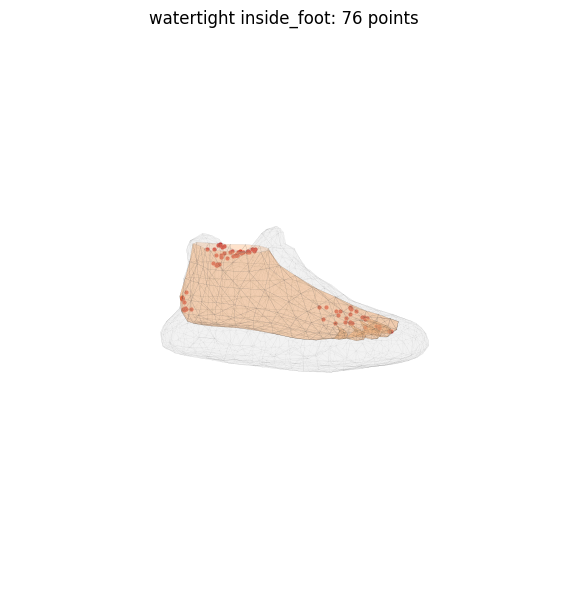

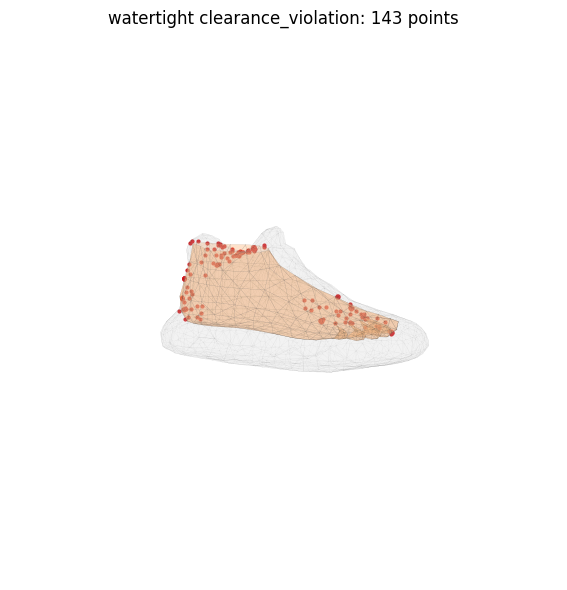

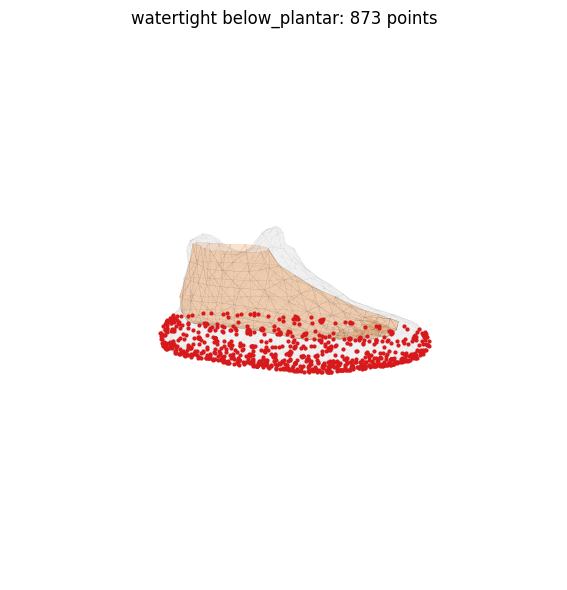

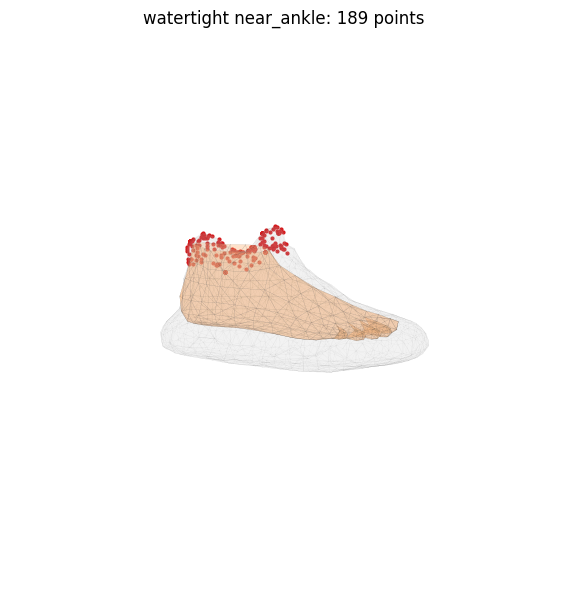

In [9]:
def plot_region_points(mesh, regions, key, title, elev=10, azim=-70):
    mask = regions[key]
    points = mesh.vertices[mask]
    points_display = to_display_coords(points, alignment) if points.shape[0] > 0 else points
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    add_mesh(ax, mesh, color="#cccccc", alpha=0.12, max_faces=3500, linewidth=0.04, alignment=alignment)
    if points.shape[0] > 0:
        ax.scatter(points_display[:, 0], points_display[:, 1], points_display[:, 2], s=4, c="#d7191c", depthshade=False)
    foot_aligned = alignment.transform_foot_to_shoe(foot_mesh.vertices)
    add_mesh(ax, MeshData(foot_aligned, foot_mesh.faces), color="#fdae6b", alpha=0.35, max_faces=900, linewidth=0.12, alignment=alignment)
    set_axes_equal(ax, [to_display_coords(mesh.vertices, alignment), to_display_coords(foot_aligned, alignment)])
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    ax.set_title(f"{title}: {int(mask.sum())} points")
    plt.tight_layout()
    plt.show()

for key in ["inside_foot", "clearance_violation", "below_plantar", "near_ankle"]:
    plot_region_points(watertight_mesh, watertight_regions, key, f"watertight {key}")


## 7. Interactive Alignment

This is the important cell. Move the foot until it looks anatomically plausible inside the shoe.

The default now automatically rotates the foot to the shoe's principal horizontal axis. The `yaw` slider is an offset on top of that automatic yaw, so use small values first.

The two most important sliders are usually:

- `length`: how much of the shoe length the foot should occupy. Smaller values usually look more realistic because the mesh is the outer shoe, not the inner cavity.
- `plantar`: how high above the outsole bottom the plantar surface sits. This should usually be near the insole/midsole level, not the absolute bottom of the sole.


In [12]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    length_w = widgets.FloatSlider(value=0.78, min=0.65, max=0.98, step=0.01, description="length")
    scale_w = widgets.FloatSlider(value=1.0, min=0.75, max=1.20, step=0.01, description="scale")
    plantar_w = widgets.FloatSlider(value=0.032, min=0.004, max=0.040, step=0.002, description="plantar")
    auto_yaw_w = widgets.Checkbox(value=True, description="auto yaw")
    align_opening_w = widgets.Checkbox(value=True, description="ankle opening")
    tx_w = widgets.FloatSlider(value=0.0, min=-0.08, max=0.08, step=0.002, description="tx")
    ty_w = widgets.FloatSlider(value=0.0, min=-0.08, max=0.08, step=0.002, description="ty")
    tz_w = widgets.FloatSlider(value=0.0, min=-0.05, max=0.05, step=0.002, description="tz")
    yaw_w = widgets.FloatSlider(value=0.0, min=-35.0, max=35.0, step=1.0, description="yaw+/-")
    pitch_w = widgets.FloatSlider(value=0.0, min=-25.0, max=25.0, step=1.0, description="pitch")
    roll_w = widgets.FloatSlider(value=0.0, min=-25.0, max=25.0, step=1.0, description="roll")
    elev_w = widgets.IntSlider(value=10, min=-5, max=60, step=1, description="elev")
    azim_w = widgets.IntSlider(value=-70, min=-180, max=180, step=5, description="azim")
    show_shell_w = widgets.Checkbox(value=True, description="shell")
    show_watertight_w = widgets.Checkbox(value=True, description="watertight")
    out = widgets.Output()

    def current_alignment():
        return make_alignment(
            length_ratio=length_w.value,
            scale_multiplier=scale_w.value,
            plantar_clearance=plantar_w.value,
            auto_yaw=auto_yaw_w.value,
            align_ankle_to_opening=align_opening_w.value,
            yaw_degrees=yaw_w.value,
            pitch_degrees=pitch_w.value,
            roll_degrees=roll_w.value,
            tx=tx_w.value,
            ty=ty_w.value,
            tz=tz_w.value,
        )

    def redraw(_=None):
        aln = current_alignment()
        with out:
            clear_output(wait=True)
            print(f"scale={aln.scale:.5f}, plantar_z={aln.plantar_z:.5f}")
            print(f"auto_yaw={aln.auto_yaw_degrees:.2f} deg, yaw_offset={yaw_w.value:.1f} deg")
            print(f"ankle opening alignment = {align_opening_w.value}; opening center = {aln.opening_center}")
            print(f"length_ratio={length_w.value:.2f}, plantar_clearance={plantar_w.value:.3f}")
            print(f"translation offset = [{tx_w.value:.3f}, {ty_w.value:.3f}, {tz_w.value:.3f}]")
            print(f"pitch/roll = [{pitch_w.value:.1f}, {roll_w.value:.1f}] degrees")
            plot_alignment(
                aln,
                elev=elev_w.value,
                azim=azim_w.value,
                show_shell=show_shell_w.value,
                show_watertight=show_watertight_w.value,
                title="interactive foot alignment",
            )

    controls = widgets.VBox([
        widgets.HBox([length_w, scale_w, plantar_w, auto_yaw_w, align_opening_w]),
        widgets.HBox([tx_w, ty_w, tz_w]),
        widgets.HBox([yaw_w, pitch_w, roll_w]),
        widgets.HBox([elev_w, azim_w, show_shell_w, show_watertight_w]),
    ])
    for w in [length_w, scale_w, plantar_w, auto_yaw_w, align_opening_w, tx_w, ty_w, tz_w, yaw_w, pitch_w, roll_w, elev_w, azim_w, show_shell_w, show_watertight_w]:
        w.observe(redraw, names="value")
    display(controls, out)
    redraw()
except Exception as exc:
    print("ipywidgets are not available here; use make_alignment(...) manually above.")
    print(type(exc).__name__ + ":", exc)


Output()

## 8. Export Diagnostic Outputs

This writes the same kind of files as the script:

- `alignment.json`
- `foot_aligned.obj`
- `shoe_regions.ply`
- `watertight_regions.ply`
- `hybrid_shell_foot_retained.obj`

The hybrid mesh is the current shell plus watertight triangles whose centroids are below the plantar band.


In [11]:
# If the interactive cell above has been run, this uses the current slider values.
# Otherwise it falls back to the default automatic alignment.
if "current_alignment" in globals():
    export_alignment = current_alignment()
else:
    export_alignment = make_alignment(
        scale_multiplier=1.0,
        tx=0.0,
        ty=0.0,
        tz=0.0,
        yaw_degrees=0.0,
        pitch_degrees=0.0,
        roll_degrees=0.0,
    )

OUT_DIR.mkdir(parents=True, exist_ok=True)
ankle_loop = export_alignment.transform_foot_to_shoe(foot_mesh.vertices[get_single_boundary_loop(foot_mesh)])
shell_regions, watertight_regions = classify_shoe_points(shell_mesh.vertices, foot_sdf, export_alignment, ankle_loop), classify_shoe_points(watertight_mesh.vertices, foot_sdf, export_alignment, ankle_loop)
foot_aligned = export_alignment.transform_foot_to_shoe(foot_mesh.vertices)
retained = select_faces_below_signed_axis(
    watertight_mesh,
    axis=export_alignment.config.shoe_up_axis,
    axis_direction=export_alignment.config.shoe_up_sign,
    plantar_value=export_alignment.plantar_z,
    band=export_alignment.config.plantar_band,
)
hybrid = make_hybrid_mesh(shell_mesh, watertight_mesh, retained)

export_alignment.save_json(OUT_DIR / "alignment.json")
write_obj_mesh(OUT_DIR / "foot_aligned.obj", MeshData(foot_aligned, foot_mesh.faces))
write_colored_ply(OUT_DIR / "shoe_regions.ply", shell_mesh, colors_from_regions(shell_regions))
write_colored_ply(OUT_DIR / "watertight_regions.ply", watertight_mesh, colors_from_regions(watertight_regions))
write_obj_mesh(OUT_DIR / "hybrid_shell_foot_retained.obj", hybrid)

summary = {
    "alignment": export_alignment.to_dict(),
    "shell_regions": region_summary(shell_regions),
    "watertight_regions": region_summary(watertight_regions),
    "retained_watertight_faces": int(retained.sum()),
    "total_watertight_faces": int(retained.shape[0]),
}
with (OUT_DIR / "summary_from_notebook.json").open("w") as f:
    json.dump(summary, f, indent=2)
    f.write("\n")

print("wrote", OUT_DIR)
print(json.dumps(summary, indent=2)[:1800])


wrote /data/abelde/projects/active/Shell_Gaussian/FootShellGaussian/output/foot_prior_debug/Adidas-Yeezy-Boost-350-V2-Static-Non-Reflective-Kids
{
  "alignment": {
    "foot_to_shoe": [
      [
        -0.09607548266649246,
        0.0,
        0.8292011022567749,
        -0.03869783505797386
      ],
      [
        0.0,
        -0.8347484469413757,
        0.0,
        -1.091460943222046
      ],
      [
        0.8292011022567749,
        0.0,
        0.09607548266649246,
        0.08957283198833466
      ],
      [
        0.0,
        0.0,
        0.0,
        1.0
      ]
    ],
    "shoe_to_foot": [
      [
        -0.13788002729415894,
        0.0,
        1.190004587173462,
        -0.11192774027585983
      ],
      [
        -0.0,
        -1.1979657411575317,
        -0.0,
        -1.307532787322998
      ],
      [
        1.190004587173462,
        0.0,
        0.13788002729415894,
        0.03370029851794243
      ],
      [
        0.0,
        0.0,
        0.0,
        1